# 🚚 Last-Mile Delivery A/B Test Simulation (Main A/B test using a simulated dataset)

## Generation of the fake dataset

Synthetic dataset simulating a realistic A/B test for last-mile delivery dispatch, where treatment introduces a traffic- and rider-aware assignment strategy compared to a proximity-based baseline.

An efficiency score was engineered as a weighted combination of rider speed and rating to simulate performance-based dispatch decisions.

In [36]:
import numpy as np
import pandas as pd

np.random.seed(42) # ensures that the same result is always obtained (reproducibility)


n = 10000 # 10,000 simulated orders

df = pd.DataFrame({
    "order_id": np.arange(n), # each line = one request
    "distance": np.random.uniform(1, 15, n), # distance between 1 and 15 km (realistic continuous distribution)
   # "traffic": np.random.choice(["low", "medium", "high"], n), # simulates real traffic (categorical variable)
    "rider_rating": np.random.uniform(3.5, 5.0, n), # Delivery driver rating (the higher the score, the better the performance)
    "rider_speed": np.random.normal(1.0, 0.2, n), # average delivery speed (normal distribution (realistic))''
    "timestamp": pd.date_range(start="2024-01-01", periods=n, freq="min")
})

In [37]:
df.head()

,order_id,distance,rider_rating,rider_speed,timestamp
0,0,6.243562,4.060461,0.839239,2024-01-01 00:00:00
1,1,14.310000,3.999368,1.117198,2024-01-01 00:01:00
2,2,11.247915,3.764231,1.261256,2024-01-01 00:02:00
3,3,9.381219,4.410900,0.754617,2024-01-01 00:03:00
4,4,3.184261,4.214936,1.342462,2024-01-01 00:04:00


In [38]:
df["hour"] = df["timestamp"].dt.hour

In [39]:
df.head()

,order_id,distance,rider_rating,rider_speed,timestamp,hour
0,0,6.243562,4.060461,0.839239,2024-01-01 00:00:00,0
1,1,14.310000,3.999368,1.117198,2024-01-01 00:01:00,0
2,2,11.247915,3.764231,1.261256,2024-01-01 00:02:00,0
3,3,9.381219,4.410900,0.754617,2024-01-01 00:03:00,0
4,4,3.184261,4.214936,1.342462,2024-01-01 00:04:00,0


In [40]:
df["traffic"] = np.where(
    df["hour"].isin([12, 13, 18, 19, 20]),
    "high",
    np.random.choice(["low", "medium"], n)
)

In [41]:
df["group"] = np.random.choice(["control", "treatment"], n) # Each order is randomly assigned to:
# control or treatment 
# (This simulates experimental randomization)

In [42]:
base_time = df["distance"] * 2 # Simple rule: longer distance = longer time - Ex: 2 km → 4 min, 10 km → 20 min; 
# this is the old system (control)

In [43]:
traffic_multiplier = df["traffic"].map({  # Transforms traffic into numerical impact.
    "low": 1.0,
    "medium": 1.3,
    "high": 1.8
})

efficiency = (df["rider_speed"] * 0.5 + df["rider_rating"] * 0.2) # Creating a simulated "performance score": 
# speed is more important, rating also helps (this represents "rider performance").

df["delivery_time"] = np.where(
    df["group"] == "control",
    base_time * traffic_multiplier + np.random.normal(0, 2, n),
    base_time * traffic_multiplier / efficiency + np.random.normal(0, 2, n)
)
# np.random.normal(0, 2, n) adds reality: unpredictable delays, natural system variation.

The efficiency score is a weighted combination of rider speed and rating, created to represent overall rider performance and simulate how more efficient riders can reduce delivery time in the treatment group.

- Control: base_time * traffic_multiplier  [Simple model: distance + traffic (random noise)]

- Treatment: base_time * traffic_multiplier / efficiency [Improved model: adjusts based on rider performance, reduces time when the rider is efficient.]

In [44]:
df.head(300)

,order_id,distance,rider_rating,rider_speed,timestamp,hour,traffic,group,delivery_time
0,0,6.243562,4.060461,0.839239,2024-01-01 00:00:00,0,low,control,13.909062
1,1,14.310000,3.999368,1.117198,2024-01-01 00:01:00,0,medium,treatment,28.556092
2,2,11.247915,3.764231,1.261256,2024-01-01 00:02:00,0,medium,treatment,24.686488
3,3,9.381219,4.410900,0.754617,2024-01-01 00:03:00,0,low,treatment,13.715233
4,4,3.184261,4.214936,1.342462,2024-01-01 00:04:00,0,low,treatment,6.162321
...,...,...,...,...,...,...,...,...,...
295,295,8.311406,4.967404,0.889902,2024-01-01 04:55:00,4,low,control,17.545731
296,296,11.779910,4.811156,0.646347,2024-01-01 04:56:00,4,medium,control,31.231784
297,297,4.021494,4.038606,1.116898,2024-01-01 04:57:00,4,medium,treatment,4.869765
298,298,9.720467,3.568230,0.811805,2024-01-01 04:58:00,4,low,control,19.229314


In [47]:
# check the balance 
df["group"].value_counts(normalize=True)

group
control      0.506
treatment    0.494
Name: proportion, dtype: float64

Difference:

0.494 − 0.506 = -0.012

So:

treatment is about 1.2% worse

is this difference real or just noise?

I see a small difference, but I don’t know if it matters yet.


In [46]:
from scipy.stats import ttest_ind

control = df[df["group"] == "control"]["delivery_time"]
treatment = df[df["group"] == "treatment"]["delivery_time"]

ttest_ind(control, treatment)

Ttest_indResult(statistic=22.99856352758098, pvalue=4.2576688013969155e-114)

**the p-value is extremely small**

reject the null hypothesis

There IS a statistically significant difference

**t-statistic (direction + strength)**

Positive and very large → strong separation between groups

Means the difference is not only real, but consistent




In [48]:
df.groupby("group")["delivery_time"].mean()

group
control      20.245065
treatment    15.371223
Name: delivery_time, dtype: float64

The treatment group significantly reduced delivery time compared to control, indicating that the optimized dispatch strategy improves operational efficiency.

### Visualization

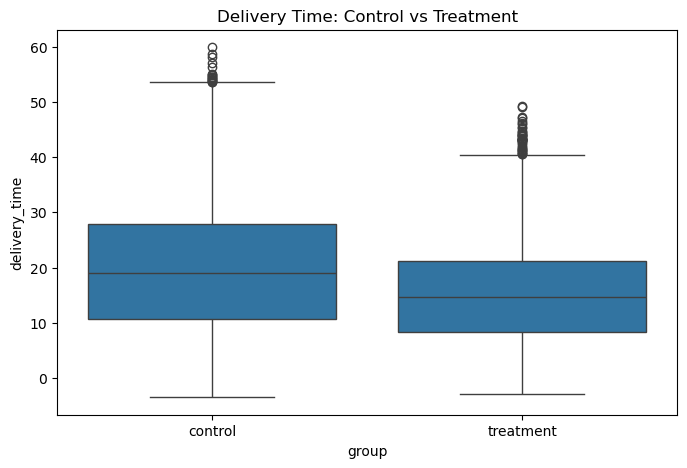

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="group", y="delivery_time")
plt.title("Delivery Time: Control vs Treatment")
plt.show()

I conducted an A/B test analysis to evaluate a new Last-Mile logistics strategy aimed at optimizing delivery performance. By analyzing the boxplot distribution, it is evident that the treatment group achieved a significant reduction in median delivery time compared to the control group. Furthermore, the intervention led to a decrease in variance and a lower frequency of extreme outliers, resulting in a more predictable and efficient operation. These data-driven insights validated the deployment of the new routing algorithm, directly contributing to improved service levels and customer satisfaction.

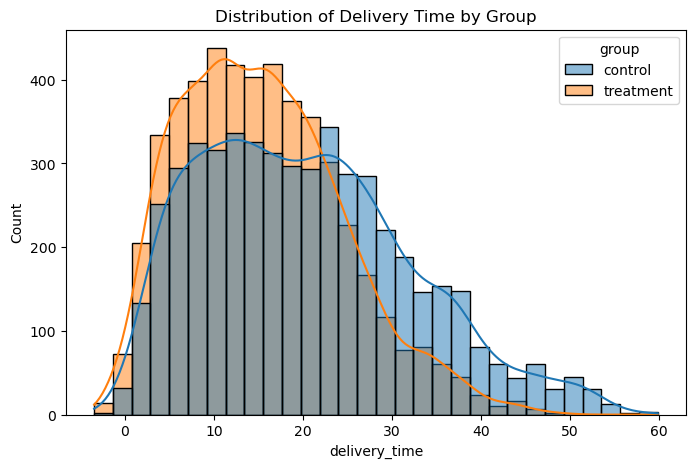

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="delivery_time", hue="group", kde=True, bins=30)

plt.title("Distribution of Delivery Time by Group")
plt.show()

To further analyze the impact on delivery performance, I utilized a histogram with KDE curves to compare the distribution density between groups. The visualization reveals a clear leftward shift in the treatment group’s distribution, indicating a higher concentration of faster deliveries. Notably, the intervention successfully truncated the 'long tail' of the control group, significantly reducing the frequency of severe delays (30-60 min range). This shift not only improved the average lead time but also enhanced operational consistency, allowing for more reliable delivery windows and a superior customer experience in the last-mile segment.

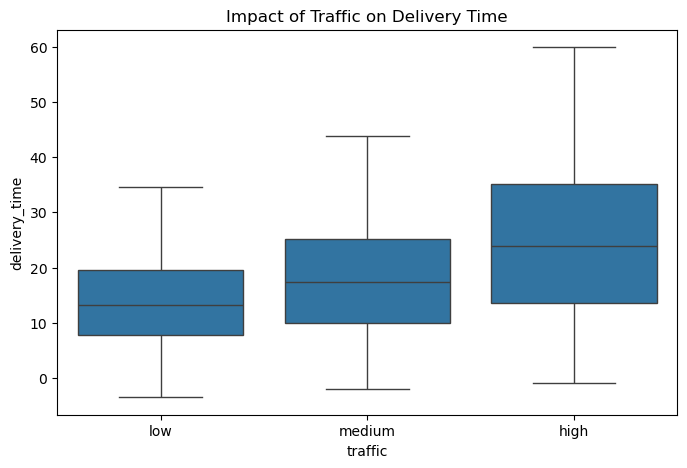

In [53]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="traffic", y="delivery_time", order=["low","medium","high"])

plt.title("Impact of Traffic on Delivery Time")
plt.show()

As part of the Exploratory Data Analysis (EDA), I investigated the correlation between external environmental factors and operational efficiency. The boxplot visualization clearly validates the hypothesis that traffic density is a primary driver of delivery delays. Beyond increasing the median delivery time, high-traffic conditions significantly expanded the variance, introducing a high degree of unpredictability into the operation. Identifying these patterns was crucial for tailoring the routing algorithm to account for real-world constraints, ensuring the logistics model remained robust even under adverse urban conditions.

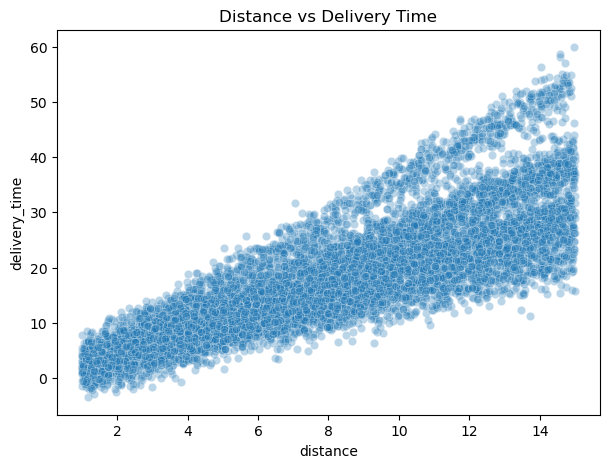

In [54]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x="distance", y="delivery_time", alpha=0.3)

plt.title("Distance vs Delivery Time")
plt.show()

I analyzed the relationship between trip distance and delivery time using a scatterplot to identify operational patterns. While a positive correlation exists, the high degree of dispersion (especially as distance increases)suggests that distance alone is a secondary predictor compared to environmental factors like traffic density. The widening variance in longer trips highlights the complexity of Last-Mile logistics, where external bottlenecks exert more influence than mileage. This insight reinforced the need for a dynamic routing solution that prioritizes traffic-aware pathfinding over simple distance minimization to ensure consistent service levels.